# Load embeddings

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from time import time
from sklearn.decomposition import PCA
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

In [2]:
# Train directory
X_train_embeddings = np.load("X_train_arcface.npy")
y_train_embeddings = np.load("y_train_embeddings.npy")

# Train embeddings need to be split into train / val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_embeddings,
    y_train_embeddings,
    test_size=0.30,      # 30% goes to val
    random_state=42,
    stratify=y_train_embeddings
)

# Test directory
X_test = np.load("X_test_arcface.npy")
y_test = np.load("y_test_embeddings.npy")

In [3]:
# ============================================================
# 1. Scaling
# ============================================================
# IMPORTANT:
# We fit the StandardScaler *only on the training data* to avoid data leakage.
# Then we use the fitted scaler to transform validation and test sets.
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit + transform on TRAIN
X_val_scaled   = scaler.transform(X_val)         # Transform only
X_test_scaled  = scaler.transform(X_test)        # Transform only

print("Scaling complete.")
print("Train scaled shape:", X_train_scaled.shape)

Scaling complete.
Train scaled shape: (20096, 512)


# Check distribution

In [4]:
emotion_names = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

def get_distribution_wide_combined(labels_dict):
    """
    labels_dict: dictionary with {dataset_name: labels_array}
    Returns a wide-format DataFrame with count and percentage combined in each cell.
    """
    combined_data = {}

    for name, labels in labels_dict.items():
        unique, counts = np.unique(labels, return_counts=True)
        total = counts.sum()
        combined_dict = {emotion_names[int(u)]: f"{c} ({c/total*100:.1f}%)"
                         for u, c in zip(unique, counts)}
        combined_data[name] = combined_dict

    # Combine into DataFrame
    df_combined = pd.DataFrame({k: pd.Series(v) for k, v in combined_data.items()}).fillna("0 (0.0%)")
    return df_combined

# Prepare input
labels_dict = {
    "Train": y_train,
    "Validation": y_val,
    "Test": y_test
}

df_wide_combined = get_distribution_wide_combined(labels_dict)
df_wide_combined

,Train,Validation,Test
angry,2797 (13.9%),1198 (13.9%),958 (13.3%)
disgust,305 (1.5%),131 (1.5%),111 (1.5%)
fear,2868 (14.3%),1229 (14.3%),1024 (14.3%)
happy,5050 (25.1%),2165 (25.1%),1774 (24.7%)
sad,3381 (16.8%),1449 (16.8%),1247 (17.4%)
surprise,2220 (11.0%),951 (11.0%),831 (11.6%)
neutral,3475 (17.3%),1490 (17.3%),1233 (17.2%)


# MLP Classifier

## How to use the validation set for choosing best parameters
1. GridSearchCV with `cv=PredefinedSplit`:
- Combine your training + validation set into one dataset.
- Create a PredefinedSplit where:
  - Training indices = 0
  - Validation indices = -1
- This ensures that all training folds are trained on the original training set and the validation set is always used for evaluating hyperparameters.
2. Test set remains untouched:
- After the best hyperparameters are chosen using the validation set, the test set is only used once for final generalization performance.

In [6]:
# ----------------------------
# 1️⃣ Combine training + validation for PredefinedSplit
# ----------------------------
# For raw features
X_train_val_raw = np.vstack([X_train_scaled, X_val_scaled])
y_train_val_raw = np.concatenate([y_train, y_val])
test_fold_raw = np.concatenate([
    np.zeros(len(X_train_scaled)),   # training
    -1 * np.ones(len(X_val_scaled))  # validation
])
ps_raw = PredefinedSplit(test_fold=test_fold_raw)

# ----------------------------
# Parameter grid for smaller, more regularized models
# ----------------------------
param_grid = {
    "hidden_layer_sizes": [(32,), (64,), (32,16), (64,32)],
    "activation": ["relu", "tanh"],
    "alpha": [0.01, 0.05, 0.1, 0.2],
    "learning_rate": ["adaptive"],
    "beta_1": [0.7, 0.8, 0.9],
    "beta_2": [0.99, 0.999]
}

# ----------------------------
# 2️⃣ GridSearch on RAW features
# ----------------------------
print("=== GridSearch MLP on RAW features ===")
grid_raw = GridSearchCV(
    MLPClassifier(
        solver="adam",
        batch_size=64,
        max_iter=300,
        early_stopping=True,
        random_state=42
    ),
    param_grid,
    cv=ps_raw,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

start_time = time()
grid_raw.fit(X_train_val_raw, y_train_val_raw)
raw_time = time() - start_time

best_raw = grid_raw.best_estimator_
train_acc_raw = best_raw.score(X_train_scaled, y_train)
val_acc_raw   = best_raw.score(X_val_scaled, y_val)
test_acc_raw  = best_raw.score(X_test_scaled, y_test)

print("✅ RAW features - Best Params:", grid_raw.best_params_)
print(f"✅ RAW features - Validation CV score: {grid_raw.best_score_:.4f}")
print(f"Training time: {raw_time:.2f}s")
print(f"Training accuracy: {train_acc_raw:.4f}")
print(f"Validation accuracy: {val_acc_raw:.4f}")
print(f"Test accuracy: {test_acc_raw:.4f}\n")

# Create a summary table
summary = pd.DataFrame({
    "Feature Type": ["Raw"],
    "Training Accuracy": [train_acc_raw],
    "Validation Accuracy": [val_acc_raw],
    "Test Accuracy": [test_acc_raw],
    "Training Time (s)": [raw_time]
})

display(summary)

=== GridSearch MLP on RAW features ===
Fitting 1 folds for each of 192 candidates, totalling 192 fits
✅ RAW features - Best Params: {'activation': 'relu', 'alpha': 0.2, 'beta_1': 0.8, 'beta_2': 0.999, 'hidden_layer_sizes': (64,), 'learning_rate': 'adaptive'}
✅ RAW features - Validation CV score: 0.4864
Training time: 78.01s
Training accuracy: 0.7422
Validation accuracy: 0.7429
Test accuracy: 0.5603



,Feature Type,Training Accuracy,Validation Accuracy,Test Accuracy,Training Time (s)
0,Raw,0.742237,0.742947,0.560323,78.008085


# Raw Features

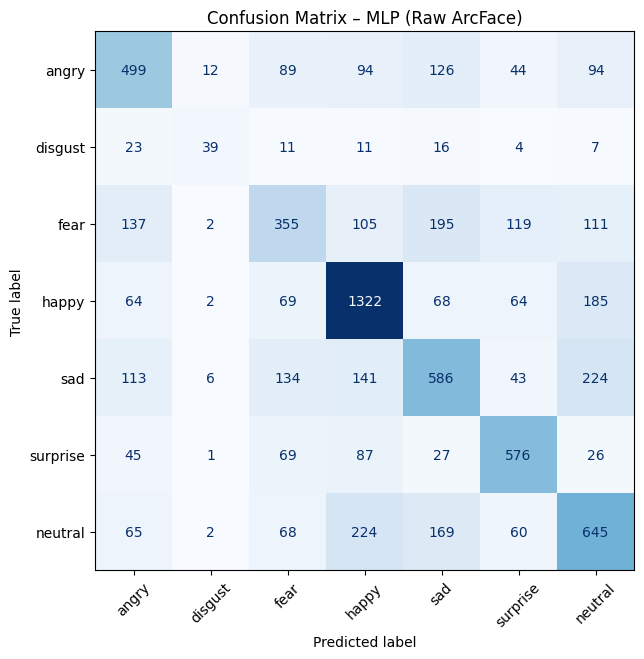

In [9]:
y_pred_raw = best_raw.predict(X_test_scaled)
cm_raw = confusion_matrix(y_test, y_pred_raw)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_raw, display_labels=emotion_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix – MLP (Raw ArcFace)")
plt.xticks(rotation=45)
plt.show()

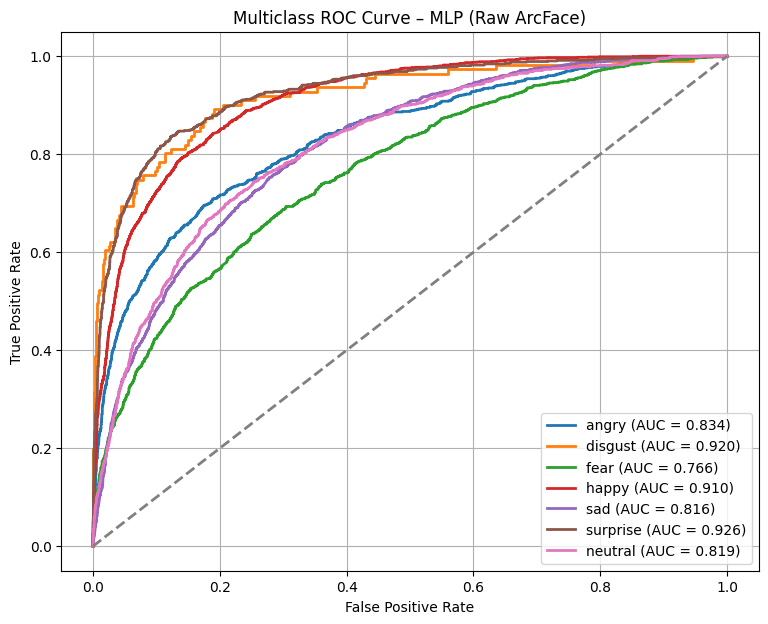

In [10]:
classes = np.unique(y_test)  # numeric class IDs
n_classes = len(classes)

# Binarize labels
y_test_bin = label_binarize(y_test, classes=classes)

# Predict probabilities
y_proba_raw = best_raw.predict_proba(X_test_scaled)

plt.figure(figsize=(9, 7))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_raw[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{emotion_names[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=2)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve – MLP (Raw ArcFace)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## How generalizability is captured

Generalization is reflected in the relationship between training, validation, and test performance:

1. Training accuracy – performance on the data the model was trained on.
- Very high training accuracy but much lower validation/test accuracy usually indicates overfitting.
2. Validation accuracy – performance on data not used for direct training, but used to tune hyperparameters.
- If validation accuracy is close to training accuracy, it suggests the model is learning generalizable patterns.
- Large gaps between training and validation indicate potential overfitting or model complexity issues.
3. Test accuracy – performance on a completely held-out set used only for final evaluation.
- Test accuracy close to training and validation accuracy indicates good generalization.
- A big drop in test accuracy compared to training/validation indicates overfitting or data mismatch.


| Pattern of Performance        | Interpretation                                                      |
|-------------------------------|----------------------------------------------------------------------|
| Train ≈ Val ≈ Test            | Well-generalized model                                              |
| Train >> Val ≈ Test           | Possible overfitting                                                |
| Train ≈ Val >> Test           | Overfitting likely due to hyperparameter tuning or data mismatch   |

Key takeaway:
- We evaluate all three metrics together to determine if the model is learning patterns that generalize.
- Good generalization is high performance on training/validation that carries over to the test set, not just high test accuracy alone.
- Validation set is critical here, because it prevents overfitting during hyperparameter selection.